# Malicious_phish.csv

In [2]:
!fusermount -u /content/drive 2>/dev/null || true
!rm -rf /content/drive

In [3]:
# 1. 務必先匯入套件
import pandas as pd
import numpy as np
import pickle
from google.colab import drive


drive.mount('/content/drive')

# 3. 讀取 CSV 檔案
csv_path = '/content/drive/MyDrive/phishing_project/cnn/malicious_phish.csv'
df = pd.read_csv(csv_path)

# 檢查是否讀取成功（印出前 5 行與資料總筆數）
print("資料集載入成功！")
print(f"總筆數與欄位數：{df.shape}")
display(df.head())

Mounted at /content/drive
資料集載入成功！
總筆數與欄位數：(651191, 2)


,url,type
0,br-icloud.com.br,phishing
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://www.garage-pirenne.be/index.php?option=...,defacement
4,http://adventure-nicaragua.net/index.php?optio...,defacement


In [ ]:
!python ml_dl.py

2026-09-27 01:31:03.155237: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
CNN 專案資料夾：
/content/drive/MyDrive/phishing_project/cnn

Loading Dataset
Dataset shape: (651191, 2)

Columns:
['url', 'type']

First 5 rows:
                                                 url        type
0                                   br-icloud.com.br    phishing
1                mp3raid.com/music/krizz_kaliko.html      benign
2                    bopsecrets.org/rexroth/cr/1.htm      benign
3  http://www.garage-pirenne.be/index.php?option=...  defacement
4  http://adventure-nicaragua.net/index.php?optio...  defacement

Dataset Information

Missing values:
url     0
type    0
dtype: int64

Label distribution:
type
benign        428103
defacement     96457
phishing   

成果:產出6 個檔案：
1. malicious_url_cnn.keras（最佳模型權重檔）
2. tokenizer.pkl（字元 Tokenizer 字典）
3. label_encoder.pkl（標籤編碼器）
4. training_config.pkl（訓練參數與測試集評估結果）
5. test_predictions.csv（測試集每筆 URL 的預測結果）
6. training_history.pkl（訓練過程 Loss / Accuracy 歷史紀錄）

① 載入已儲存的 .pkl 檔案看數據

In [ ]:
import pickle

HISTORY_PATH = '/content/drive/MyDrive/phishing_project/cnn/training_history.pkl'

with open(HISTORY_PATH, 'rb') as f:
    history = pickle.load(f)

print("✅ 成功載入訓練歷史紀錄！")
print("Train Loss:", history['loss'])
print("Val Loss:", history['val_loss'])
print("Train Accuracy:", history['accuracy'])
print("Val Accuracy:", history['val_accuracy'])
print("Best Val Loss:", history['best_val_loss'])

✅ 成功載入訓練歷史紀錄！
Train Loss: [0.19204343855381012, 0.11293137073516846, 0.09676618874073029, 0.08833274245262146, 0.08154982328414917, 0.07707563787698746, 0.0732945129275322, 0.07031954824924469, 0.06801079213619232, 0.06608884781599045, 0.06334713101387024, 0.061222657561302185, 0.060516033321619034, 0.059007611125707626, 0.05743454024195671, 0.05627959966659546, 0.055889736860990524]
Val Loss: [0.10508745163679123, 0.08598092198371887, 0.07801330834627151, 0.07564688473939896, 0.0803876593708992, 0.0685572475194931, 0.06816163659095764, 0.06626293063163757, 0.06495323777198792, 0.06546741724014282, 0.07220965623855591, 0.06326556205749512, 0.06485459953546524, 0.06277275085449219, 0.06822583079338074, 0.06461029499769211, 0.06498468667268753]
Train Accuracy: [0.9393807649612427, 0.9658921957015991, 0.970560610294342, 0.9727575778961182, 0.9748665690422058, 0.9760479927062988, 0.9770737886428833, 0.9778723120689392, 0.9785991907119751, 0.9789779782295227, 0.9798133969306946, 0.980278193

② 數據整合與規格統一

1. 讀取分散的兩份紀錄: ①從 training_history.pkl 載入每個 Epoch 的訓練與驗證數據（Loss 與 Accuracy）。② 從 training_config.pkl 載入模型在 Test 集上的最終評估指標（Accuracy、Macro F1、Weighted F1）。

2. 清洗欄位並打包:將原本 key 名稱較模糊的 loss、accuracy 重命名為更直觀明確的 train_loss、train_acc，並與測試集的 F1-score 等指標合併到同一個字典 unified_history 中。
3. 存成全新的單一統整檔
把整理好的字典重新存回 Google Drive，儲存為 unified_training_history.pkl。

In [ ]:
import pickle
import os

# 1. 確保雲端硬碟目錄存在
BASE_DIR = '/content/drive/MyDrive/phishing_project/cnn'
os.makedirs(BASE_DIR, exist_ok=True)

# 2. 從已儲存的 pkl 檔案正確載入 CNN 的訓練歷史與設定
with open(os.path.join(BASE_DIR, 'training_history.pkl'), 'rb') as f:
    cnn_history = pickle.load(f)

# 補上讀取 cnn_config，避免 NameError
with open(os.path.join(BASE_DIR, 'training_config.pkl'), 'rb') as f:
    cnn_config = pickle.load(f)

# 3. 整合為統一的統整檔
unified_history = {
    'train_loss': cnn_history.get('loss'),
    'val_loss': cnn_history.get('val_loss'),
    'train_acc': cnn_history.get('accuracy'),
    'val_acc': cnn_history.get('val_accuracy'),

    # 結合測試評估數據
    'test_accuracy': cnn_config.get('test_accuracy'),
    'test_macro_f1': cnn_config.get('test_macro_f1'),
    'test_weighted_f1': cnn_config.get('test_weighted_f1'),
}

# 4. 儲存為統一的統整檔
unified_path = os.path.join(BASE_DIR, 'unified_training_history.pkl')
with open(unified_path, 'wb') as file:
    pickle.dump(unified_history, file)

print(f"✅ 成功將所有歷史與測試數據統整完畢！")
print(f"檔案已儲存至：{unified_path}")
print("\n統整後的內容包含：")
print(list(unified_history.keys()))

✅ 成功將所有歷史與測試數據統整完畢！
檔案已儲存至：/content/drive/MyDrive/phishing_project/cnn/unified_training_history.pkl

統整後的內容包含：
['train_loss', 'val_loss', 'train_acc', 'val_acc', 'test_accuracy', 'test_macro_f1', 'test_weighted_f1']


training_history.pkl（訓練過程 Loss / Accuracy 歷史紀錄）

③ 畫 Loss / Accuracy Curve

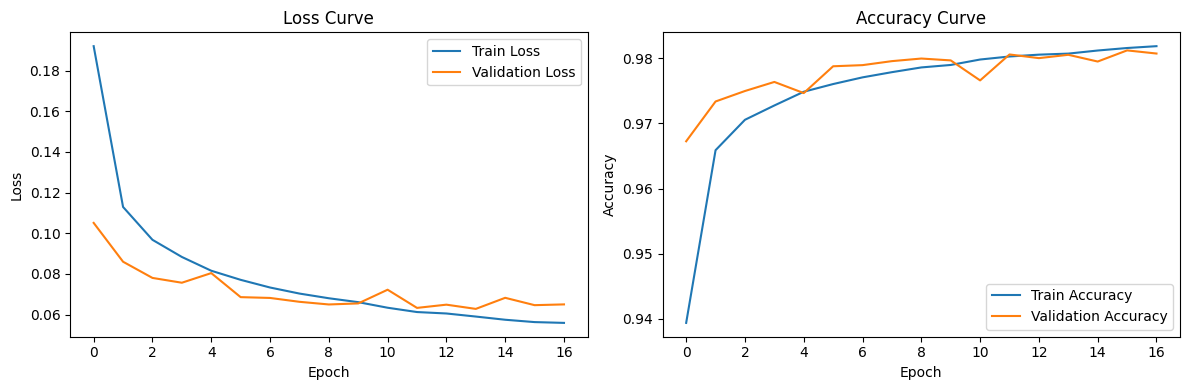

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# =========================
# 1. Loss Curve
# =========================
plt.subplot(1, 2, 1)

# 原生 Keras 的訓練 Loss 鍵名是 'loss'
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')

plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# =========================
# 2. Accuracy Curve
# =========================
plt.subplot(1, 2, 2)

# 原生 Keras 的訓練 Accuracy 鍵名是 'accuracy'
plt.plot(history['accuracy'], label='Train Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')

plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# uci-ml-phishing-dataset.csv

In [ ]:
import numpy as np
import pandas as pd
from google.colab import drive

# 1. 掛載 Google 雲端硬碟（若已掛載可跳過）
drive.mount('/content/drive')

# 2. 讀取 UCI 釣魚網址資料集
csv_path = '/content/drive/MyDrive/phishing_project/uci_mlp/uci-ml-phishing-dataset.csv'  # 請確認檔名與路徑是否相符
df = pd.read_csv(csv_path)

# 3. 檢查資料集資訊
print("資料集載入成功！")
print(f"總筆數與欄位數：{df.shape}")
print("\n[資料前 5 筆]")
display(df.head())

print("\n[欄位名稱與型態]")
print(df.info())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
資料集載入成功！
總筆數與欄位數：(11055, 32)

[資料前 5 筆]


,id,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,1,-1,1,1,1,-1,-1,-1,-1,-1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,2,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,3,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,4,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,5,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1



[欄位名稱與型態]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   id                           11055 non-null  int64
 1   having_IP_Address            11055 non-null  int64
 2   URL_Length                   11055 non-null  int64
 3   Shortining_Service           11055 non-null  int64
 4   having_At_Symbol             11055 non-null  int64
 5   double_slash_redirecting     11055 non-null  int64
 6   Prefix_Suffix                11055 non-null  int64
 7   having_Sub_Domain            11055 non-null  int64
 8   SSLfinal_State               11055 non-null  int64
 9   Domain_registeration_length  11055 non-null  int64
 10  Favicon                      11055 non-null  int64
 11  port                         11055 non-null  int64
 12  HTTPS_token                  11055 non-null  int64
 13  Request_URL                  11055 

In [ ]:
!python ppu_dl.py

Model / result directory:
/content/drive/MyDrive/phishing_project/uci_mlp

=== Dataset Information ===
Dataset shape: (11055, 32)

Columns:
['id', 'having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report', 'Result']

=== Result Distribution ===
Result
 1    6157
-1    4898
Name: count, dtype: int64

Unique Result values:
[-1  1]

'id' column removed.

=== Feature Information ===
X shape: (11055, 30)
y shape: (11055,)

Number of missing values:
0

Feature data types:
int64    30
Name: count, dtype: int64

All features are numeric.

=== Dataset 

成果:產出的 6 個檔案
1. uci_mlp_model.pkl (模型權重檔)用途：儲存訓練完成的 MLP 神經網路模型（含 64 $\rightarrow$ 32 兩層隱藏層的權重與偏置）。後續應用：推論（Inference）或模型融合（Fusion）時可以直接載入使用，無需重新訓練。
2. uci_scaler.pkl (特徵縮放器)用途：儲存基於 Training set 計算出來的 StandardScaler 標準化參數（Mean 與 Variance）。後續應用：未來有新的 URL 特徵輸入時，必須使用同一個 Scaler 進行 transform()，避免 Feature Data Drift 或轉換尺度不一致。
3. training_history.pkl (訓練歷程紀錄)用途：紀錄訓練過程中的 Loss 變化曲線 (loss_curve_)，以及 Validation 與 Test 集的最終評估數據（Accuracy、Macro F1、Weighted F1）。後續應用：供繪圖區塊繪製學習曲線（Learning Curve）或進行跨模型績效對比。
4. training_config.pkl (訓練組態檔)用途：紀錄該次的實驗超參數與設定（如資料分割比例 75/15/10、learning_rate=1e-3、batch_size=32 等）。後續應用：確保實驗可重複性（Reproducibility），方便撰寫論文或實驗報告時查閱參數設定。
5. label_mapping.pkl (標籤映射字典)用途：儲存類別編號與真實語意的映射關係。後續應用：模型輸出數字 0 或 1 時，供前端或後續系統直接對應轉換為文字類別。
6. test_predictions.csv (測試集預測結果明細)用途：將 10% 的 Test set 資料加上 true_label（真實標籤）與 predicted_label（模型預測結果）後存成 CSV。後續應用：方便分析 False Positive（誤報）與 False Negative（漏報）的特定特徵案例。

①畫 Loss / Accuracy Curve

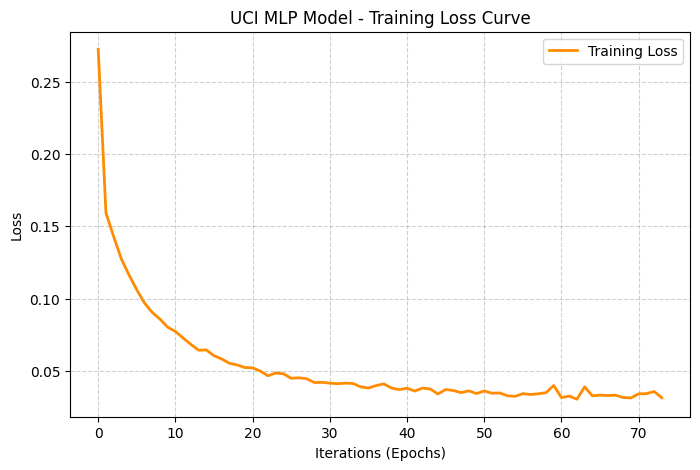

總迭代次數 (Iterations): 74
最終訓練 Loss: 0.0316
驗證集準確率 (Val Accuracy): 0.9668
測試集準確率 (Test Accuracy): 0.9557


In [ ]:
import joblib
import os
import matplotlib.pyplot as plt

# 1. 設定與 ppu_dl.py 相同的輸出路徑
BASE_DIR = '/content/drive/MyDrive/phishing_project/uci_mlp'
history_path = os.path.join(BASE_DIR, 'training_history.pkl')

# 2. 載入訓練歷史
training_history = joblib.load(history_path)

# 3. 取得 MLP 的 loss 曲線
loss_curve = training_history['loss_curve']

# 4. 繪製圖表
plt.figure(figsize=(8, 5))
plt.plot(loss_curve, label='Training Loss', color='darkorange', linewidth=2)
plt.title('UCI MLP Model - Training Loss Curve')
plt.xlabel('Iterations (Epochs)')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# 5. 印出對應的評估指標
print(f"總迭代次數 (Iterations): {training_history['n_iter']}")
print(f"最終訓練 Loss: {training_history['final_loss']:.4f}")
print(f"驗證集準確率 (Val Accuracy): {training_history['validation_accuracy']:.4f}")
print(f"測試集準確率 (Test Accuracy): {training_history['test_accuracy']:.4f}")

# PhiUSIIL_Phishing_URL_Dataset.csv

# 實驗1:跨資料集基準評估與零樣本測試（Zero-Shot Baseline）

1. 模型與資料載入：載入預訓練的 1D-CNN 惡意網址辨識模型與 UCI MLP 模型，並讀取 PhiUSIIL 資料集。

2. UCI 特徵轉接器（URL-to-UCI Adapter）：由於 UCI MLP 模型原本接收 30 個特徵，而 PhiUSIIL 結構不同(54 個特徵)，腳本會從 URL 本身重建 9 個可觀察的 UCI 特徵，其餘無法從網址直接取得的特徵則以 UCI 訓練集的平均值（中立值）填補。
3. 固定與凍結資料切分（Strict Evaluation Standard）：將 PhiUSIIL 按 75% / 15% / 10% 進行分層抽樣（Stratified Split）。將切分索引（train_idx, val_idx, test_idx）存檔。整個評估過程只在 10% 的測試集（Test Set）上進行，確保完全無資料洩漏（Data Leakage）。
4. 模型推論與 Late Fusion 晚期融合：獲得 p_cnn（CNN 預測為惡意的機率）。獲得 p_mlp（MLP 經由 Adapter 預測為惡意的機率）。進行 Late Fusion（簡單 50/50 權重平均：$0.5 \times p_{\text{CNN}} + 0.5 \times p_{\text{MLP}}$）。
5. 指標計算與數據匯出：計算 Accuracy、Precision、Recall、F1-Score 與 AUC。輸出 Confusion Matrix、評估柱狀圖 (baseline_metrics.png)、預測明細表 (phi_test_predictions.csv) 與實驗設定 (baseline_config.json)。

關於第二項重建UCI特徵說明:
UCI 論文對這 9 個特徵的官方定義對照
1. url_length (網址長度)UCI 論文定義：統計發現釣魚網站為了隱藏真實目的，網址通常極長。官方規則：長度 $< 54$ $\rightarrow$ 1 (Legitimate)$54 \le$ 長度 $\le 75$ $\rightarrow$ 0 (Suspicious)長度 $> 75$ $\rightarrow$ -1 (Phishing)
2. having_ip_address (是否包含 IP)UCI 論文定義：檢查 Hostname 是否為 IP 位址（如 192.168.1.1 或十六進位 IP）。官方規則：是 IP $\rightarrow$ -1；否 $\rightarrow$ 1。
3. shortining_service (短網址服務)UCI 論文定義：檢查是否使用知名縮網址服務（如 bit.ly, goo.gl, tinyurl 等）隱藏真實網址。官方規則：使用短網址 $\rightarrow$ -1；無 $\rightarrow$ 1。
4. having_at_symbol (含有 @ 符號)UCI 論文定義：URL 中的 @ 符號會導致瀏覽器忽略 @ 前的所有內容，攻擊者常用來偽裝網址（例如 [http://google.com@evil.com](http://google.com@evil.com)）。官方規則：含有 @ $\rightarrow$ -1；無 $\rightarrow$ 1。
5. double_slash_redirecting (雙斜線重導向)UCI 論文定義：正常 URL 只會在協定處出現 ://。如果在網址路徑中再次出現 //，代表該網址正在進行轉址欺騙。官方規則：:// 之後還有 // $\rightarrow$ -1；無 $\rightarrow$ 1。
6. prefix_suffix (連字號 - 偽裝)UCI 論文定義：合法企業的網域名稱極少使用連字號 -，而釣魚網站常利用 - 來偽造品牌（例如 paypal-security.com）。官方規則：Domain 包含 - $\rightarrow$ -1；無 $\rightarrow$ 1。

7. having_sub_domain (子網域層級)UCI 論文定義：移除頂級網域（TLD，如 .com）與主網域後，計算剩餘的子網域數量。官方規則：0 個子網域（如 google.com） $\rightarrow$ 11 個子網域（如 mail.google.com） $\rightarrow$ 02 個以上子網域（如 login.account.google.com） $\rightarrow$ -1
8. https_token (域名內混入 HTTPS 字串)UCI 論文定義：檢查 Domain Name 本身是否寫入 "https"（如 [http://https-bank.com](http://https-bank.com)）來混淆使用者。官方規則：Domain 包含 "https" $\rightarrow$ -1；無 $\rightarrow$ 1。
9. abnormal_url (異常網址)UCI 論文定義：檢查 Hostname 是否正常包含在網址中，或是與 WHOIS 記錄/伺服器回應不符。官方規則：網址結構異常 $\rightarrow$ -1；正常 $\rightarrow$ 1。

In [ ]:
!python baseline.py

2026-09-29 04:32:14.793049: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
01 BASELINE: LOAD PRETRAINED CNN + MLP
2026-09-29 04:32:20.064733: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1790656340.066347    1399 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
CNN loaded: /content/drive/MyDrive/phishing_project/cnn/malicious_url_cnn.keras
MLP loaded: /content/drive/MyDrive/phishing_project/uci_mlp/uci_mlp_model.pkl
CNN classes: ['benign' 'defacement' 'malware' 

成果:完整 11 個檔案對照清單
資料集凍結分割索引（3 個 .npy）

1. phi_train_idx.npy（訓練集索引）

2. phi_val_idx.npy（驗證集索引）

3. phi_test_idx.npy（測試集索引）

模型預測機率與真實標籤（4 個 .npy）

1. phi_cnn_probability.npy（CNN 惡意機率）

2. phi_mlp_probability.npy（MLP 惡意機率）

3. phi_late_probability.npy（Late Fusion 機率）

4. phi_labels.npy（PhiUSIIL 正確標籤）

測試集詳細數據與評估（2 個 .csv）

1. baseline_results.csv（三大模型 Metric 指標總表）

2. phi_test_predictions.csv（測試集每筆 URL 的詳細預測對照表）

視覺化圖表與組態（2 個檔案）

1. baseline_metrics.png（指標柱狀圖）

2. baseline_config.json（實驗參數與版本紀錄）

# 發現:
CNN_ZeroShot（字元級 1D-CNN）

1. 表現特徵： 召回率（Recall）極高（0.9914），但準確率（Accuracy）偏低（0.4244）、誤報率高。

2. 混淆矩陣分析： 模型幾乎把所有樣本都預測為「惡意/釣魚」（預測為正類的樣本高達 13,485 + 10,008 = 23,493 筆），在負類（Benign）上完全失效（True Negatives 為 0）。

3. 原因解析： 該 CNN 是在 malicious_phish.csv（包含大量 URL 字串特徵）上訓練的，直接搬到 PhiUSIIL 資料集做 Zero-Shot 時，分界閾值或類別對應出現嚴重的域偏移（Domain Shift），導致模型對正常網址產生大量誤判。

MLP_ZeroShot（基於 UCI 特徵的 MLP）

1. 表現特徵： 整體表現相對平衡，準確率為 0.6575，精確率（Precision）達 0.7575。

2. 混淆矩陣分析： 能夠正確辨識大部分的正常網址（True Negatives = 12,534），但召回率偏低（0.2942），漏掉了相當多實際的釣魚網址（7,125 筆 False Negatives）。

3. 原因解析： MLP 依賴結構化的工程特徵（30維），雖然對正常樣本的特徵掌握度較好，但面對未見過的釣魚樣本分佈，模型趨於保守。

Late_Fusion_ZeroShot（後期融合基準）

1. 表現特徵： 結合 CNN 與 MLP 兩者機率輸出的後期融合（Late Fusion），各項指標呈現折衷狀態（Accuracy 0.5114、F1 0.5336、AUC 0.5600）。

2. 原因解析： 由於兩者在 Zero-Shot 下的預測分佈尚未經過對齊或微調（Fine-tuning），單純的後期融合無法直接發揮互補優勢，反而受到 CNN 過度激進的預測所影響。

# 結論與後續優化方向
1. 基準現狀確立： 此階段成功凍結了 PhiUSIIL 的測試集並建立了無微調（Zero-Shot）的 Baseline 效能，證明直接遷移單一預訓練模型或簡單的後期融合在跨資料集時會面臨嚴重的分佈不對齊問題。

2. 下一步重心： 接下來進入 fusion.py 階段時，應著手進行特徵層級或決策層級的重新訓練與融合調校，利用訓練集來適應 PhiUSIIL 的資料分佈，才能有效抑制 CNN 的盲目誤報，大幅提升整體 F1-score 與 AUC。

# 實驗2:特徵融合、目標領域適應與資料效率實驗

## 特徵萃取與融合架構：

(1)CNN 分支：凍結預訓練 CNN，透過修改後的網路結構提取全域最大池化（Global MaxPooling）特徵向量。

(2)MLP 分支：凍結預訓練 UCI MLP，提取其最終隱藏層的激發表示。

(3)中間融合（Intermediate Fusion）：將 CNN 特徵與 MLP 隱藏層特徵進行串接（Concatenation）。

## 子實驗1（目標領域適應 / Target-Domain Adaptation）：
利用 PhiUSIIL 的 75% 訓練集，在凍結主幹模型的前提下，訓練輕量級的適應頭（Adaptation Head，含 Dense 與 Dropout），評估 CNN 適應版、MLP 適應版與中間融合的表現。

## 子實驗2（從頭訓練 / From-Scratch Comparison）：

CNN 從頭訓練：在 PhiUSIIL 訓練集上從隨機初始化開始訓練一個全新的 1D-CNN。

MLP 從頭訓練：在 UCI 特徵空間下從隨機初始化訓練一個全新的 MLP。

## 子實驗3（資料效率 / Data Efficiency）：
測試在不同的目標領域訓練資料比例（1%、5%、10%、25%、50%、75%）下，適應模型的效能變化曲線，評估資料需求與模型表現的關係。

In [5]:
!python fusion.py

2026-09-30 01:16:39.956018: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
LOAD MODELS / DATA & EXTRACT REPRESENTATIONS
2026-09-30 01:16:43.901884: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1790731003.903320   19253 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
/usr/local/lib/python3.13/dist-packages/keras/src/trainers/trainer.py:212: UserWarning: Model doesn't support `jit_compile=True`. Proceeding with `jit_compile=False`.
  warnings.warn(
2026-09-30 01:

成果:

📁fusion/ 根目錄下的 16 個檔案：
1. 模型與權重檔 (.keras)：cnn_adaptation_head.keras、mlp_adaptation_head.keras、intermediate_fusion_adaptation.keras（實驗一的微調模型）cnn_from_scratch.keras、mlp_from_scratch.keras（實驗二從頭訓練的對照組模型）
2. 預測機率結果檔 (.npy)：cnn_adaptation_probability.npy、mlp_adaptation_probability.npy、intermediate_fusion_probability.npycnn_from_scratch_probability.npy、mlp_from_scratch_probability.npy
3. 實驗數據與分析報表 (.csv)：experiment2_results.csv、experiment2_test_predictions.csvexperiment3_results.csv
4. 工具與設定檔 (.pkl)：scratch_tokenizer.pkl

📁 fusion/representations/ 子資料夾下的 6 個檔案：
1. cnn_embeddings.npy（CNN 萃取出的特徵矩陣）
2. mlp_hidden.npy（MLP 隱藏層特徵矩陣）
3. fusion_H.npy（兩者融合後的 $H$ 矩陣）
4. labels.npy（真實標籤）
5. original_train_idx.npy / original_val_idx.npy / original_test_idx.npy（資料集切分索引）
6. phiusiil_metadata.csv（中介對照清單）

## 1. 隨機分割 vs 分組分割 F1 分數比較圖


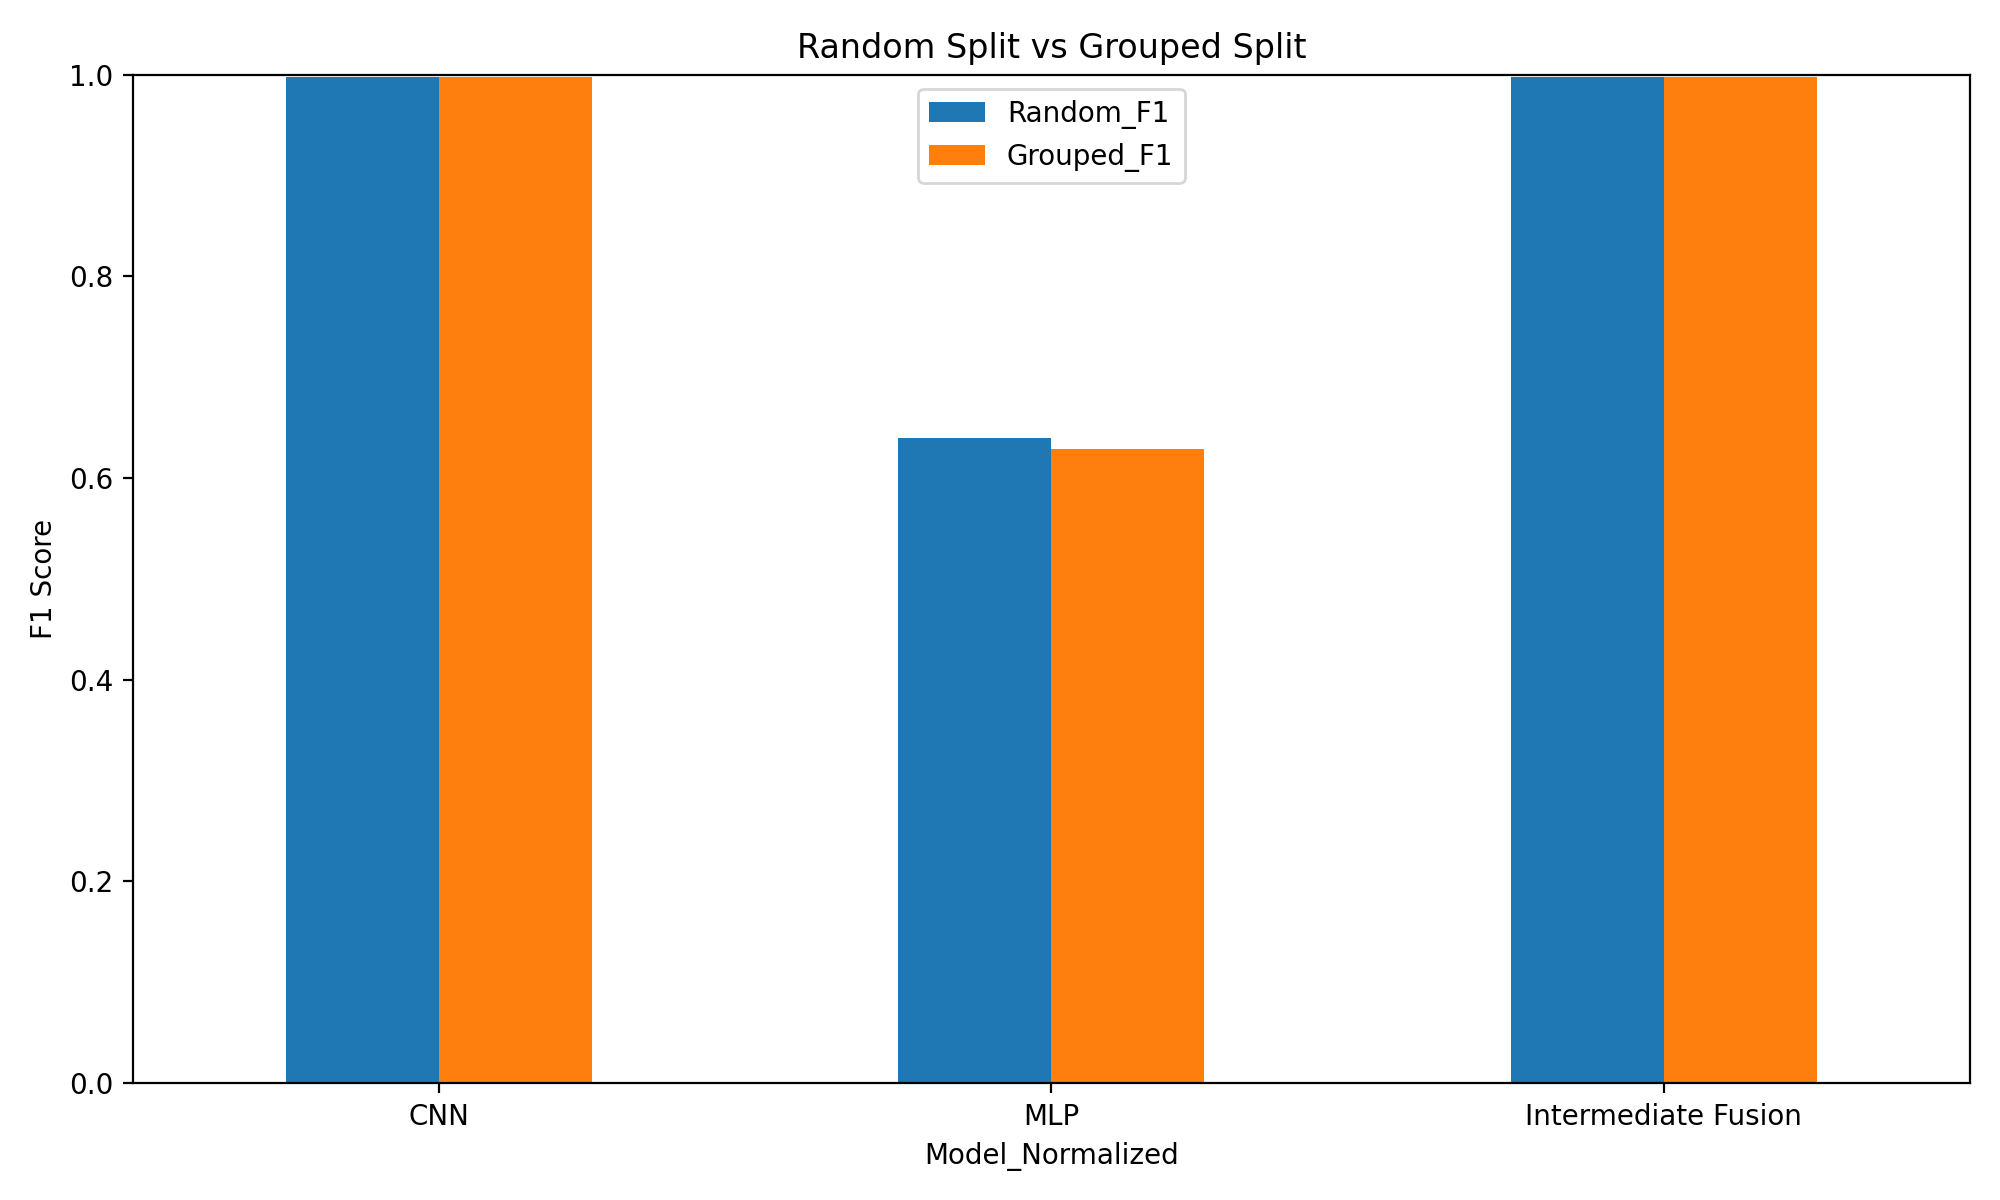

--------------------------------------------------
## 2. 資料效率分析 — F1 表現圖


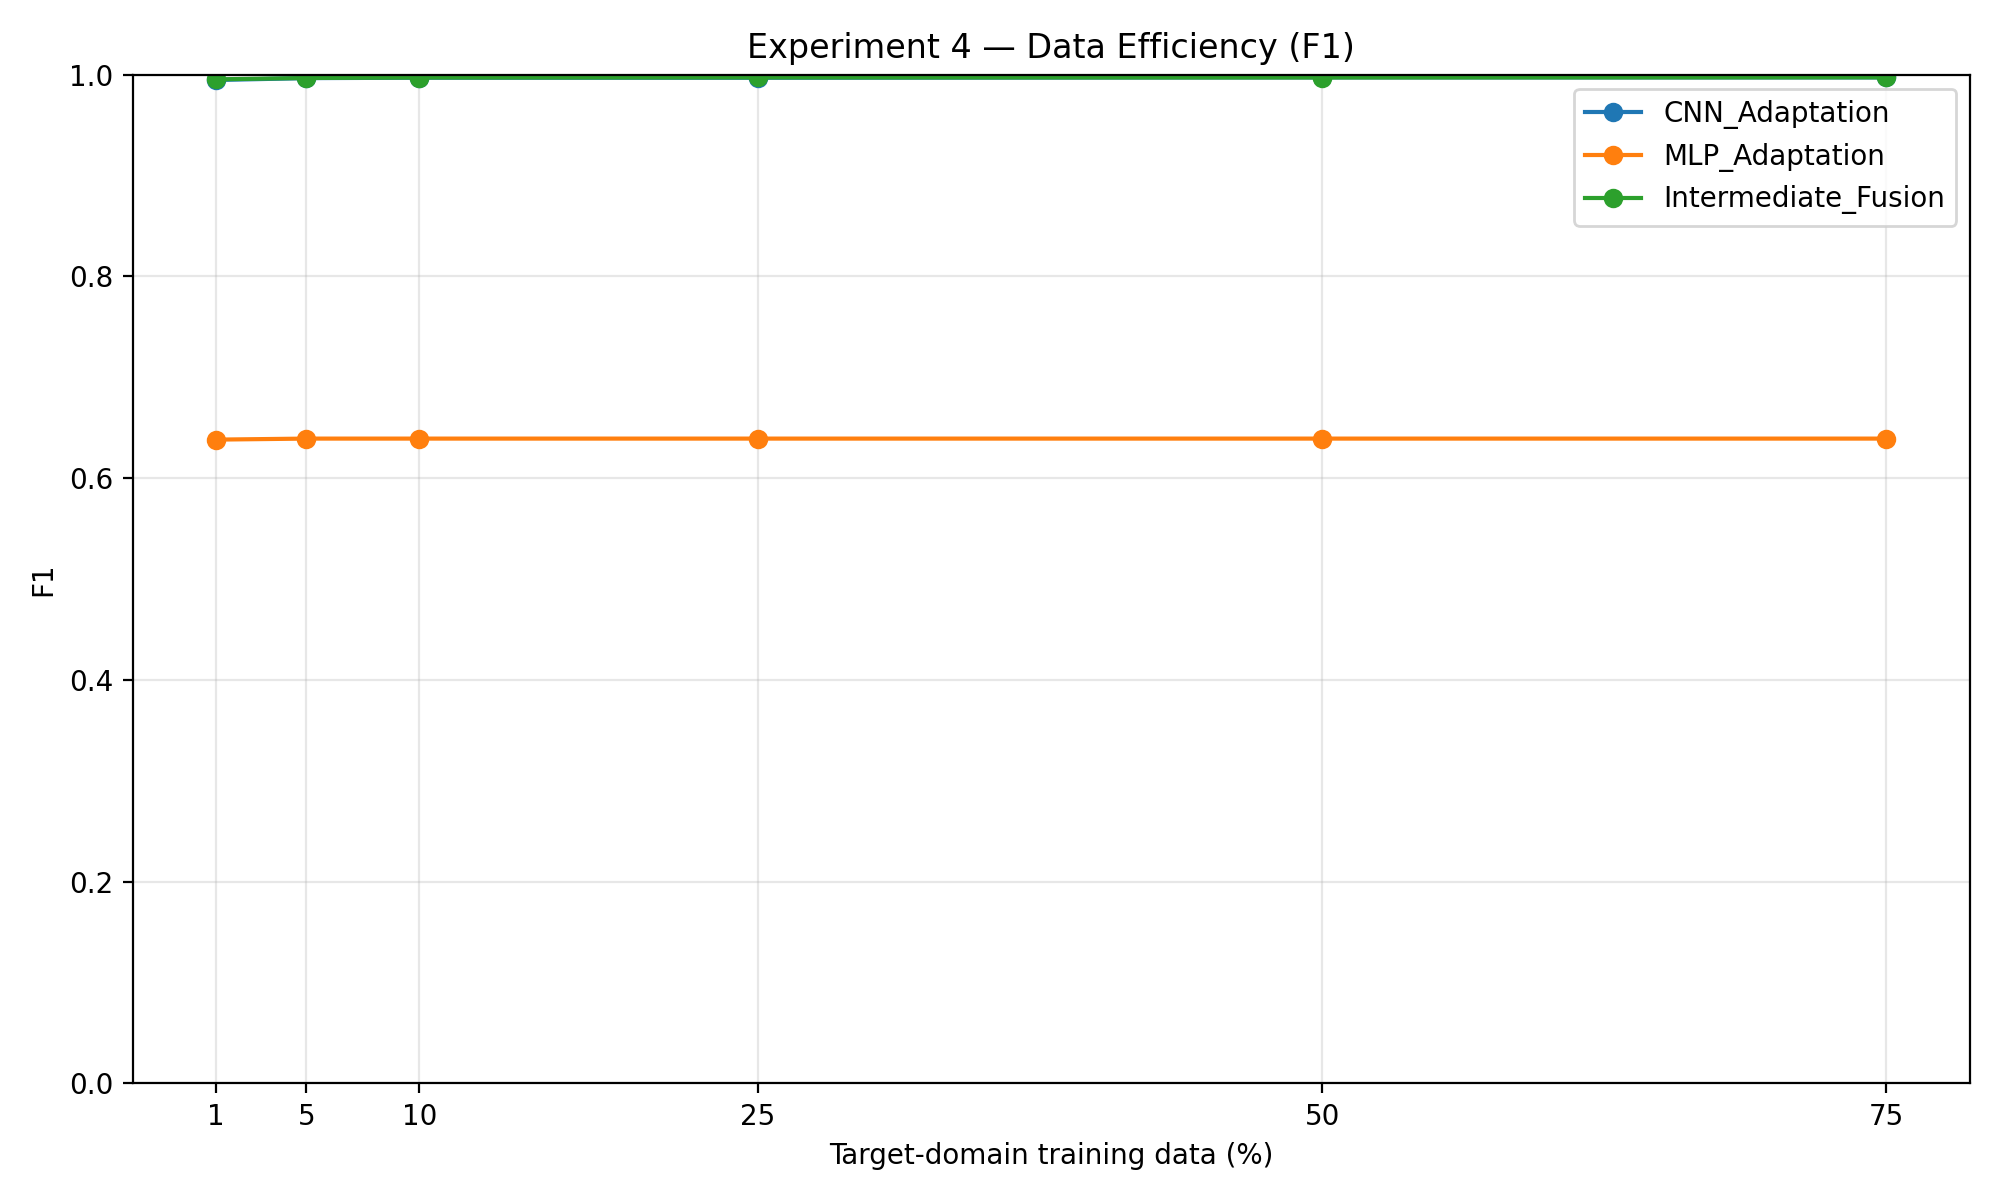

--------------------------------------------------
## 3. 資料效率分析 — AUC 表現圖


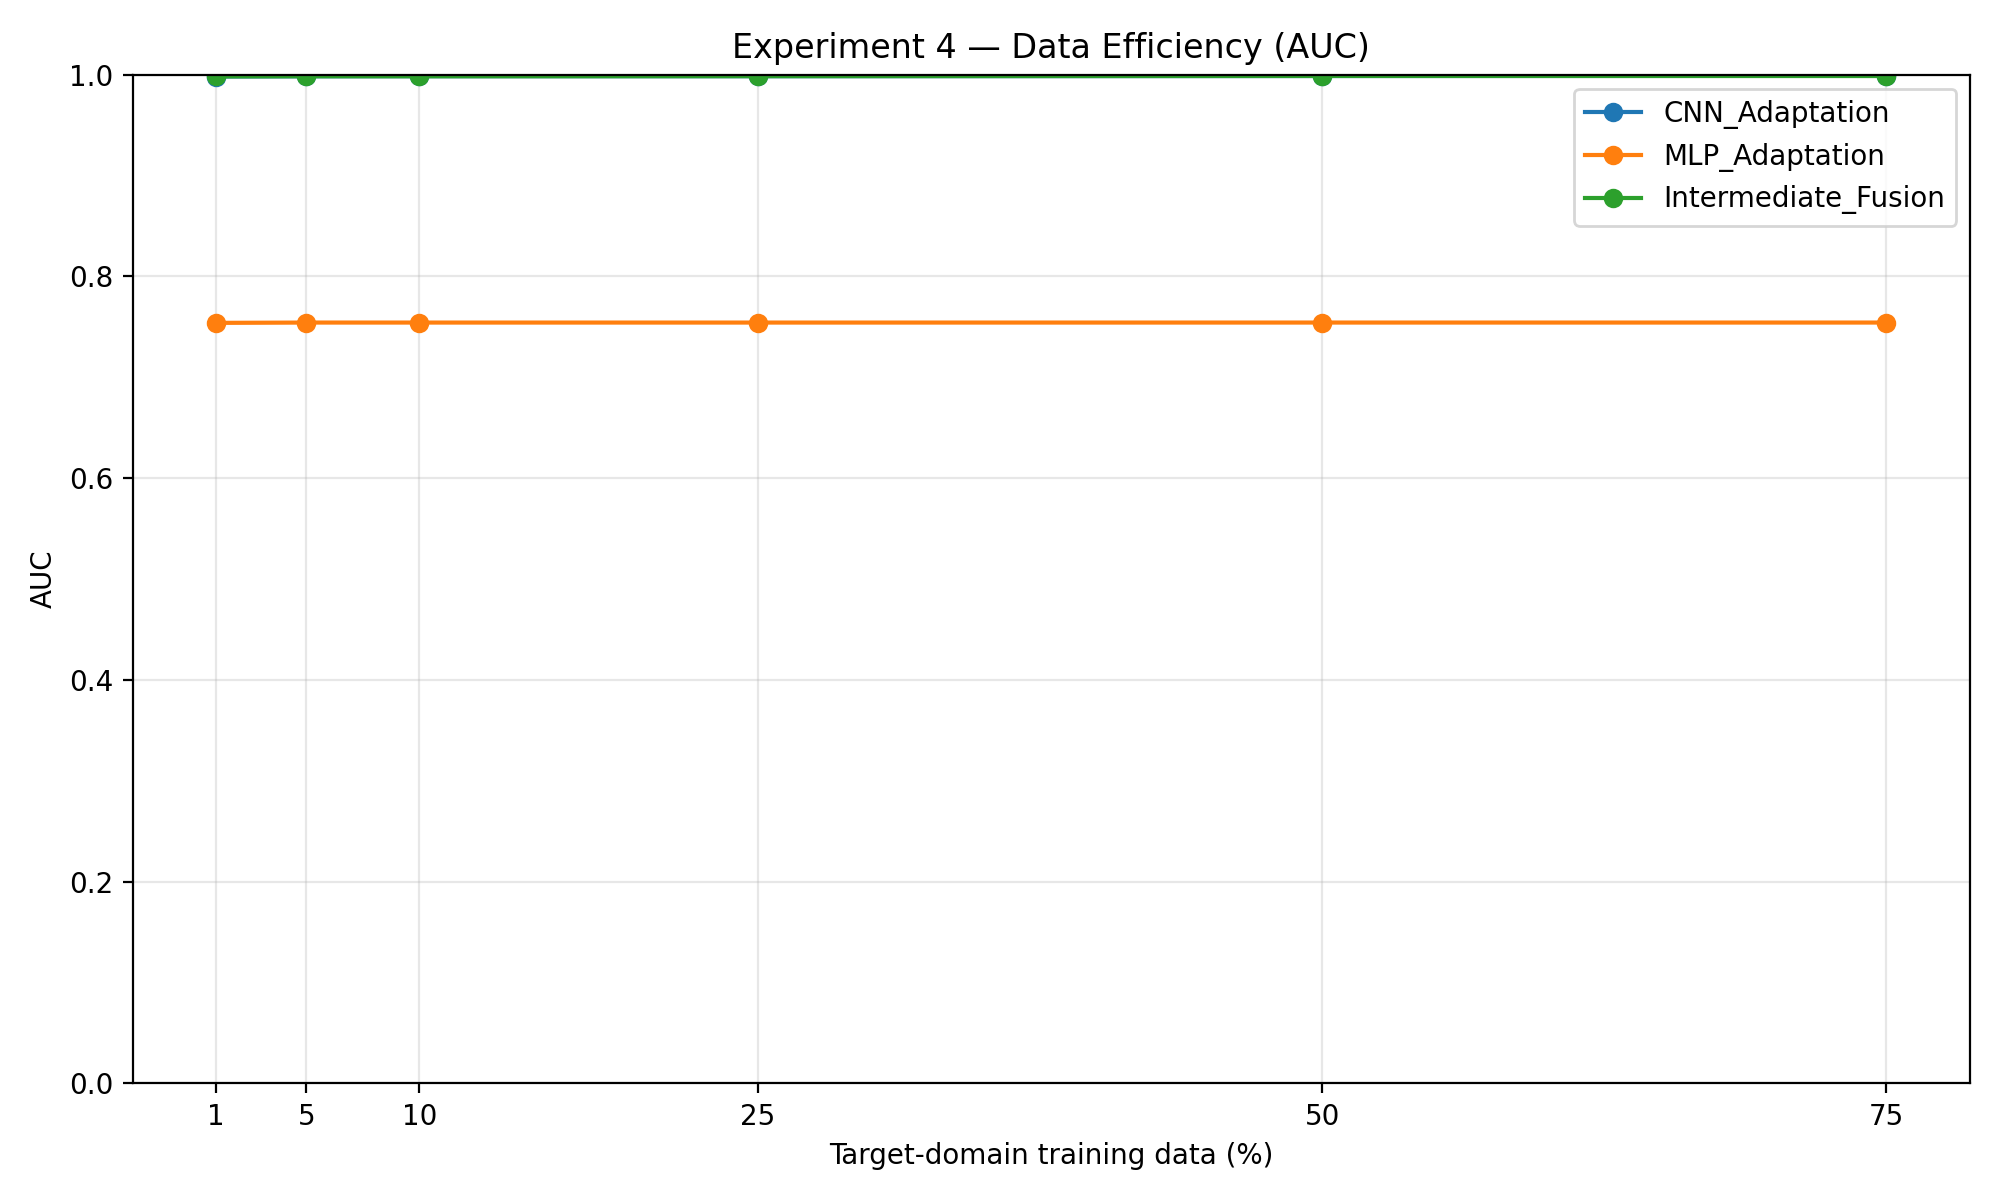

--------------------------------------------------


In [5]:
import os
from IPython.display import Image, display

# 定義圖片所在的根目錄
fusion_dir = "/content/drive/MyDrive/phishing_project/fusion"
efficiency_dir = "/content/drive/MyDrive/phishing_project/data_efficiency"
grouped_dir = os.path.join(fusion_dir, "grouped_sensitivity")

# 要顯示的圖片清單與其對應標題
image_tasks = [
    {
        "title": "## 1. 隨機分割 vs 分組分割 F1 分數比較圖",
        "path": os.path.join(grouped_dir, "random_vs_grouped_F1.png")
    },
    {
        "title": "## 2. 資料效率分析 — F1 表現圖",
        "path": os.path.join(efficiency_dir, "data_efficiency_F1.png")
    },
    {
        "title": "## 3. 資料效率分析 — AUC 表現圖",
        "path": os.path.join(efficiency_dir, "data_efficiency_AUC.png")
    }
]

# 依序檢查並顯示圖片
for task in image_tasks:
    print(task["title"])
    if os.path.exists(task["path"]):
        display(Image(filename=task["path"]))
        print("-" * 50)
    else:
        print(f"找不到圖片檔案：{task['path']}")
        print("-" * 50)

# 發現
子實驗一 — 目標領域適應 (Target-Domain Adaptation)
1. CNN_Adaptation：表現極佳，準確度（Accuracy）高達 99.78%，AUC 約 0.9987，F1 分數達 0.9974。
2. MLP_Adaptation：表現相對較弱，準確度約 75.16%，AUC 為 0.7543，F1 分數為 0.6392。
3. Intermediate_Fusion (中間特徵融合)：表現與 CNN 微調相當，準確度為 99.77%，AUC 為 0.9986，F1 分數為 0.9973。

子實驗二 — 從頭訓練 (From Scratch)
1. CNN_From_Scratch：從頭訓練的 CNN 模型同樣展現出強大效能，準確度達 99.81%，AUC 為 0.9989，F1 分數為 0.9978。
2. MLP_From_Scratch：準確度與 AUC 表現與實驗二相同（約 75.16% 與 0.7543）。

子實驗三 — 資料效率分析 (Data Efficiency)此部分測試了在不同訓練資料比例（從 1% 到 75%）下模型的表現，結果顯示：
1. 高效能的資料縮減：即使僅使用 1% 的訓練資料（1,768 筆樣本），CNN_Adaptation 與 Intermediate_Fusion 依然能維持超過 99.5% 的高準確度與 0.998 的 AUC。
2. 隨著資料量從 1% 增加至 75%（132,634 筆樣本），CNN 與融合模型的各項指標穩定維持在極高水準（Accuracy $\approx 99.77\%$、AUC $\approx 0.9988$），顯示模型對資料量的依賴度低，具備優異的小樣本適應與泛化能力。
3. 相對地，純 MLP 架構在所有資料比例下的表現均停滯在約 75.16% 的準確度。

# 總結:
(一)捨去純 MLP 模型:

從實驗數據來看，純 MLP 架構（無論是微調還是從頭訓練）在各項指標上均有明顯瓶頸：

1. 效能停滯不前：在所有實驗與資料比例下，純 MLP 的準確度與 AUC 均被封頂在 約 75.16%，F1 分數也僅有 0.6392，遠落後於 CNN 的 99% 以上水準。

2. 手動特徵工程的侷限性：純 MLP 依賴基於傳統啟發式規則所提取的數值特徵（如長度、有無特殊符號等），這些特徵在面對新型或經過混淆的釣魚網址時，缺乏足夠的辨別力與泛化空間，無法有效區分複雜的惡意特徵。因此，單純依賴 MLP 無法滿足高精確度的資安防護需求。

(二)透過「魯棒性（Robustness）」決定最終採用 CNN 還是 Intermediate_Fusion:

雖然從目前的準確度與資料效率來看，CNN_Adaptation與 Intermediate_Fusion表現不相上下，但要決定最終上限或作為核心架構的模型，必須依賴接下來的魯棒性（Robustness，抗干擾與泛化能力）測試來做最終裁決。

# 實驗3



Grouped Sensitivity Analysis（群組敏感度分析）

目的:評估隨機切分（Random Split）是否因「資料集內部重複或高度相似的 URL」而引發資料洩漏（Data Leakage），導致模型表現被過度高估（Optimistic Bias）。

為排除此干擾，我們實施 Grouped Split（群組切分） 策略：

1. URL 群組化：將經過標準化（Normalized）後相同的 URL（或共用相同 Domain/Prefix 的網址）歸為同一 Group。

2. 嚴格隔離：以 Group 為單位切分資料集，確保 Train、Validation 與 Test 三個子集間完全沒有相同的 URL Group 重疊。

3. 模型重訓與對比：在此無重複環境下重新訓練並測試 CNN、MLP 及 Fusion 架構，比較兩者在 F1-score 與 ROC-AUC 的表現差異。

若兩者效能差異微小，即證實模型的高準確度來自於真實的特徵泛化能力，而非對重複樣本的盲目記憶。

In [6]:
!python group_sensitivity.py

2026-09-30 01:38:25.290644: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
GROUPED URL SPLIT SENSITIVITY ANALYSIS

Loading representations...

Representation shapes:
CNN embedding: (235795, 128)
MLP hidden: (235795, 32)
Fusion H: (235795, 160)
Labels: (235795,)
Metadata: (235795, 3)

CHECKING URL COLUMN

Metadata columns: ['row_index', 'URL', 'label']

CREATING NORMALIZED URL GROUPS

Normalizing URLs...

Normalized URL groups created.
Total rows: 235795
Unique groups: 235159
Duplicate rows: 636
Duplicate rate: 0.2697%

CREATING GROUPED TRAIN / VALIDATION / TEST SPLIT

Train: 176863 (75.01%)
Validation: 35353 (14.99%)
Test: 23579 (10.00%)

GROUP LEAKAGE CHECK

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0

No normalized URL group lea

# 成果:
1. 模型權重檔案（3 個）

cnn_grouped_adaptation.keras（CNN 適應層最佳模型）

mlp_grouped_adaptation.keras（MLP 適應層最佳模型）

fusion_grouped_adaptation.keras（Intermediate Fusion 適應層最佳模型）

2. 資料與分割索引檔案（5 個）

normalized_url_groups.csv（正規化後的網址群組清單）

grouped_split_assignment.csv（資料集分割對應表）

grouped_train_idx.npy（訓練集陣列索引）

grouped_val_idx.npy（驗證集陣列索引）

grouped_test_idx.npy（測試集陣列索引）

3. 實驗結果與預測檔案（3 個）

grouped_sensitivity_results.csv（各模型效能評估總表）

grouped_test_predictions.csv（測試集真實標籤與各模型預測機率）

random_vs_grouped_comparison.csv（隨機分割與分組分割對比表）*

4. 圖表與設定檔（2 個）

random_vs_grouped_F1.png（隨機與分組分割的 F1 分數視覺化比較圖）*

grouped_sensitivity_config.json（實驗設定與環境參數）

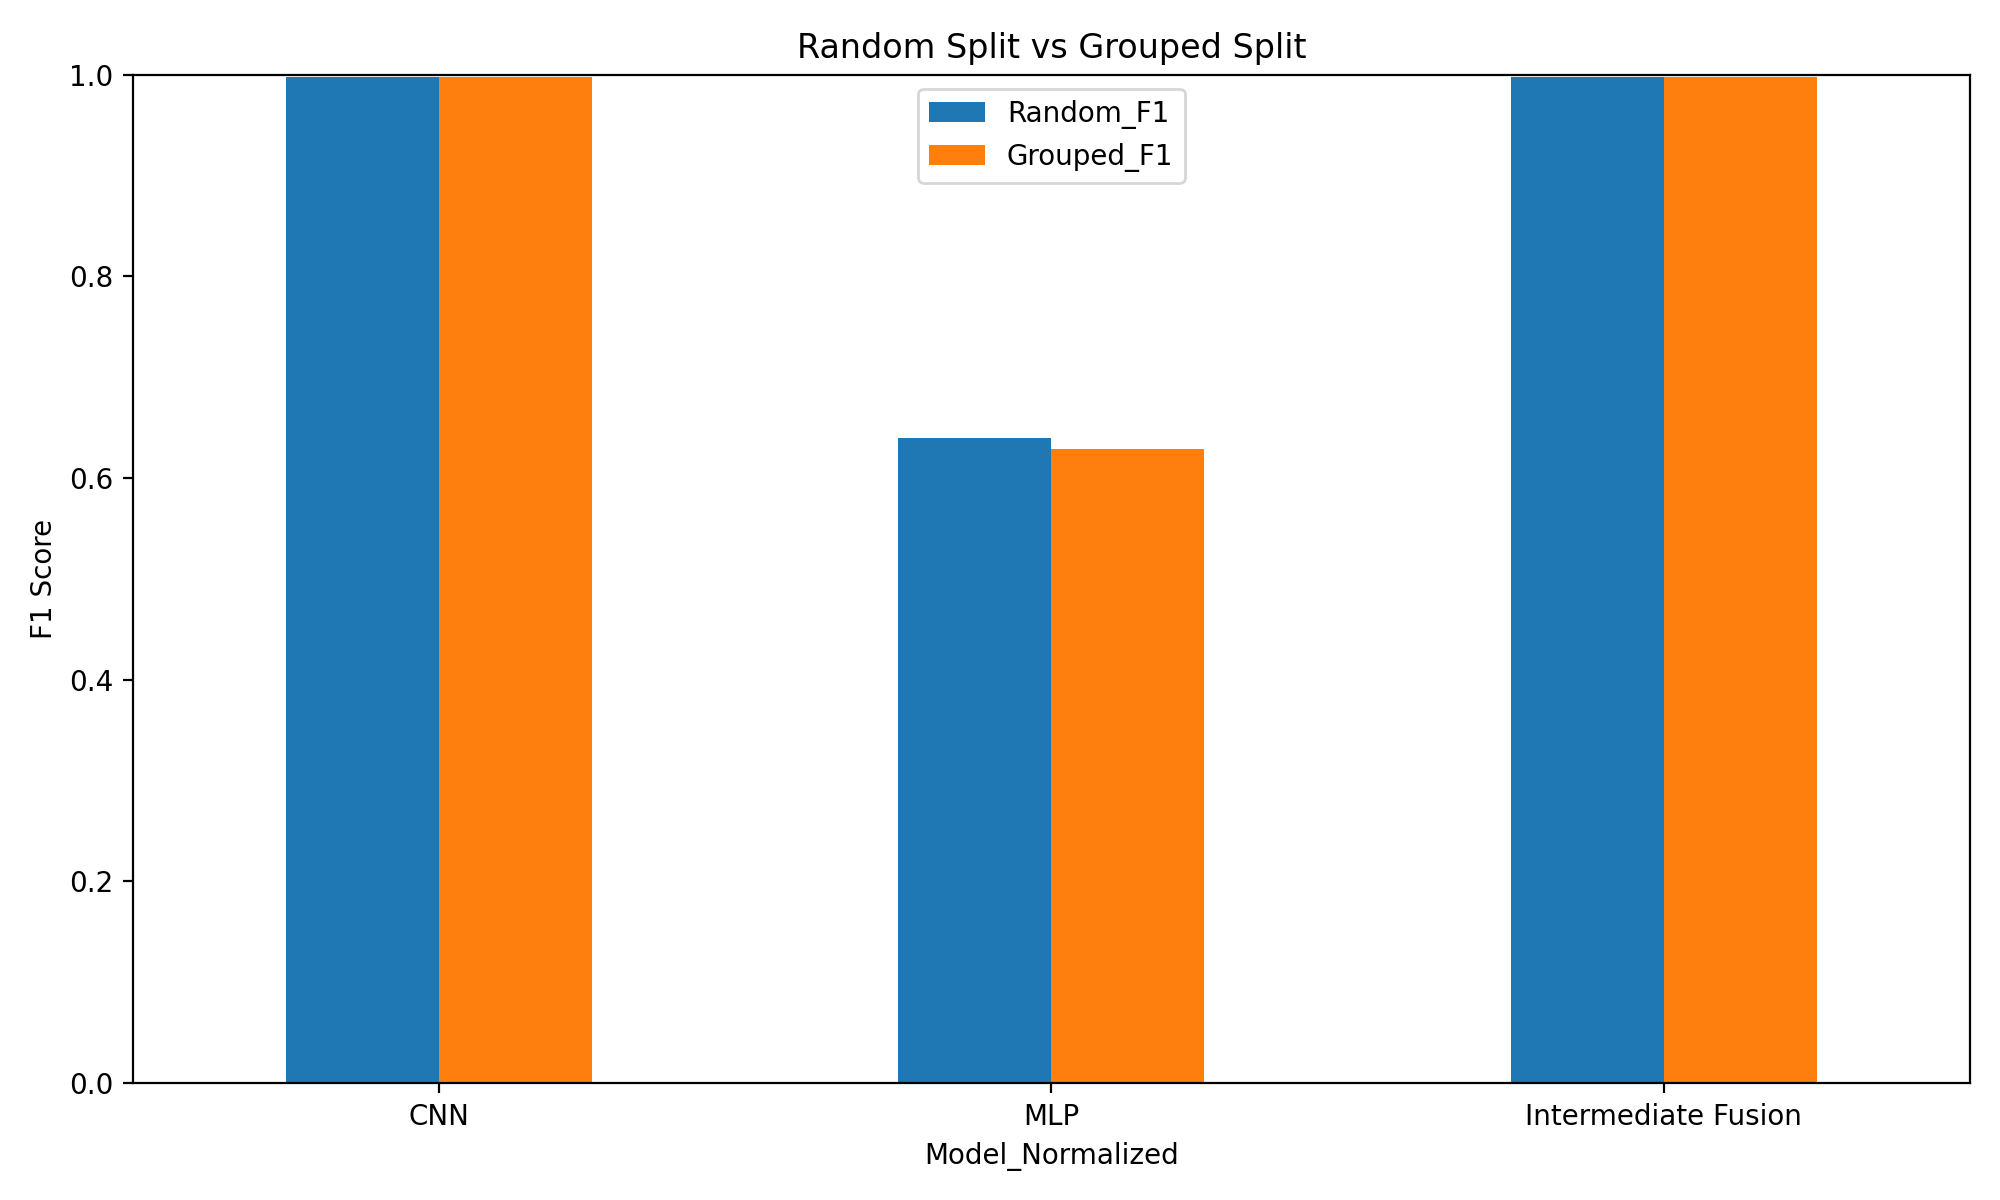

In [4]:
from IPython.display import Image, display

# 圖片儲存的路徑
image_path = "/content/drive/MyDrive/phishing_project/fusion/grouped_sensitivity/random_vs_grouped_F1.png"

# 在 Colab 中顯示圖片
display(Image(filename=image_path))

# 發現:
資料集群組化處理：

1. 總樣本數：235,795 筆（包含 235,159 個獨立 URL 群組與 636 筆重複資料，重複率約 0.27%）。

2. 無洩漏驗證（Leakage Check）：Train ∩ Validation、Train ∩ Test 以及 Validation ∩ Test 的交集皆為 0，成功杜絕資料洩漏。

各模型在群組分割下的測試表現：

1. CNN 群組適應模型 (cnn_grouped_adaptation)：

Accuracy：0.9981 | Precision：0.9999 | Recall：0.9957 | F1-score：0.9978 | AUC：0.9993

2. MLP 群組適應模型 (mlp_grouped_adaptation)：

Accuracy：0.7466 | Precision：0.8355 | Recall：0.5039 | F1-score：0.6286 | AUC：0.7460

融合架構模型 (fusion_grouped_adaptation)：

Accuracy：0.9982 | Precision：0.9998 | Recall：0.9960 | F1-score：0.9979 | AUC：0.9993

隨機切分與群組切分之比較（Random vs. Grouped Comparison）
從最終產出的比較表可以看出，群組化切分（嚴格防範洩漏）與過去隨機切分的效能差異非常微小：

1. CNN 差異：F1-score 僅微幅上升 0.0004（AUC 微升 0.0006）。

2. MLP 差異：F1-score 微幅下降 0.0106（AUC 下降 0.0082）。

3. Fusion 差異：F1-score 微幅上升 0.0005（AUC 微升 0.0006）。


# 結論:

證實模型高度泛化能力：由於嚴格以群組切分後，模型的表現（特別是 CNN 與 Fusion 架構）幾乎沒有下降，這證明了模型的高準確度是來自於真實且穩健的特徵泛化能力，而不是靠記憶重複樣本（Memorization）來達到過擬合。

# 實驗4:魯棒性測試



為模擬真實世界中攻擊者試圖規避檢測的手段，定義了 5 種擾動函數：
1. slash (AddSlash)：在 URL 結尾強制加上斜線 /（如 domain.com $\rightarrow$ [domain.com/](https://domain.com/)）。
2. dot (AddDot)：在 URL 結尾強制加上點號 .（如 domain.com $\rightarrow$ domain.com.）。
3. hyphen_query (AddHyphenQuery)：把 ? 替換為 -? 或在結尾加 -。
4. add_query (AddQuery)：在 URL 後面附加無關的 Query 參數（如 ?q=test 或 &q=test）。
5. change_case(ChangeCase)：將 URL 大小寫互換（如 Http://... $\rightarrow$ hTTP://...）。

In [ ]:
!python robustness.py

2026-09-28 01:56:33.371130: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-28 01:56:39.205079: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1790560599.207104    3738 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
CNN embedding extractor created successfully.
Embedding dimension: (None, 128)
03 ROBUSTNESS EXPERIMENT
Test samples: 23580

Running: Original
2026-09-28 01:56:53.949195: I external/local_xla/xla/service/service.cc:163] XLA service 0x78e13c002

In [ ]:
# 設定 pandas 顯示所有行與欄位，避免被省略
pd.set_option('display.max_rows', None)      # 顯示所有行
pd.set_option('display.max_columns', None)   # 顯示所有欄位
pd.set_option('display.width', 1000)         # 調整寬度避免換行過於凌亂

In [ ]:
import pandas as pd
import os

# 定義魯棒性結果的路徑
ROBUSTNESS_DIR = '/content/drive/MyDrive/phishing_project/robustness'

# 1. 讀取並顯示原始評估與各擾動下的表現結果
results_path = os.path.join(ROBUSTNESS_DIR, 'robustness_results.csv')
if os.path.exists(results_path):
    df_results = pd.read_csv(results_path)
    print("📊 【魯棒性測試總結表 (Robustness Results)】")
    display(df_results)
else:
    print(f"找不到檔案: {results_path}")

# 2. 讀取並顯示效能衰退（Degradation）分析數據
degradation_path = os.path.join(ROBUSTNESS_DIR, 'robustness_degradation.csv')
if os.path.exists(degradation_path):
    df_deg = pd.read_csv(degradation_path)
    print("\n📉 【模型效能衰退分析 (Degradation Analysis)】")
    display(df_deg)
else:
    print(f"找不到檔案: {degradation_path}")

📊 【魯棒性測試總結表 (Robustness Results)】


,Perturbation,Model,Accuracy,Precision,Recall,F1,AUC
0,Original,CNN_ZeroShot,0.355513,0.382594,0.823477,0.522452,0.535912
1,Original,MLP_ZeroShot,0.668193,0.772106,0.319168,0.451640,0.559337
2,Original,Late_Fusion_ZeroShot,0.695674,0.802612,0.383457,0.518970,0.598871
3,Original,CNN_Adaptation,0.997795,1.000000,0.994849,0.997418,0.998697
4,Original,MLP_Adaptation,0.751612,0.845114,0.514017,0.639236,0.754271
5,Original,Intermediate_Fusion,0.997668,0.999900,0.994651,0.997269,0.998580
6,AddSlash,CNN_ZeroShot,0.420356,0.423638,0.981773,0.591878,0.319315
7,AddSlash,MLP_ZeroShot,0.668405,0.772379,0.319663,0.452182,0.538467
8,AddSlash,Late_Fusion_ZeroShot,0.337405,0.368163,0.764735,0.497038,0.505467
9,AddSlash,CNN_Adaptation,0.428117,0.428117,1.000000,0.599555,0.519777



📉 【模型效能衰退分析 (Degradation Analysis)】


,Perturbation,Model,Delta_Accuracy,Delta_Precision,Delta_Recall,Delta_F1,Delta_AUC,Relative_F1_Drop
0,AddSlash,CNN_ZeroShot,-0.064843,-0.041044,-0.158296,-0.069426,2.165967e-01,-0.132885
1,AddSlash,MLP_ZeroShot,-0.000212,-0.000273,-0.000495,-0.000542,2.086940e-02,-0.001201
2,AddSlash,Late_Fusion_ZeroShot,0.358270,0.434450,-0.381278,0.021932,9.340424e-02,0.042261
3,AddSlash,CNN_Adaptation,0.569678,0.571883,-0.005151,0.397863,4.789205e-01,0.398893
4,AddSlash,MLP_Adaptation,0.335793,0.424118,-0.457256,0.051847,7.708692e-02,0.081107
5,AddSlash,Intermediate_Fusion,0.569550,0.571783,-0.005349,0.397714,4.903127e-01,0.398803
6,AddDot,CNN_ZeroShot,-0.024555,-0.016234,-0.059633,-0.027042,2.954942e-01,-0.051760
7,AddDot,MLP_ZeroShot,0.000000,0.000000,0.000000,0.000000,1.458253e-03,0.000000
8,AddDot,Late_Fusion_ZeroShot,0.027735,0.040278,0.057454,0.062268,1.658451e-01,0.119983
9,AddDot,CNN_Adaptation,0.567769,0.571076,-0.004953,0.397109,2.954883e-02,0.398137


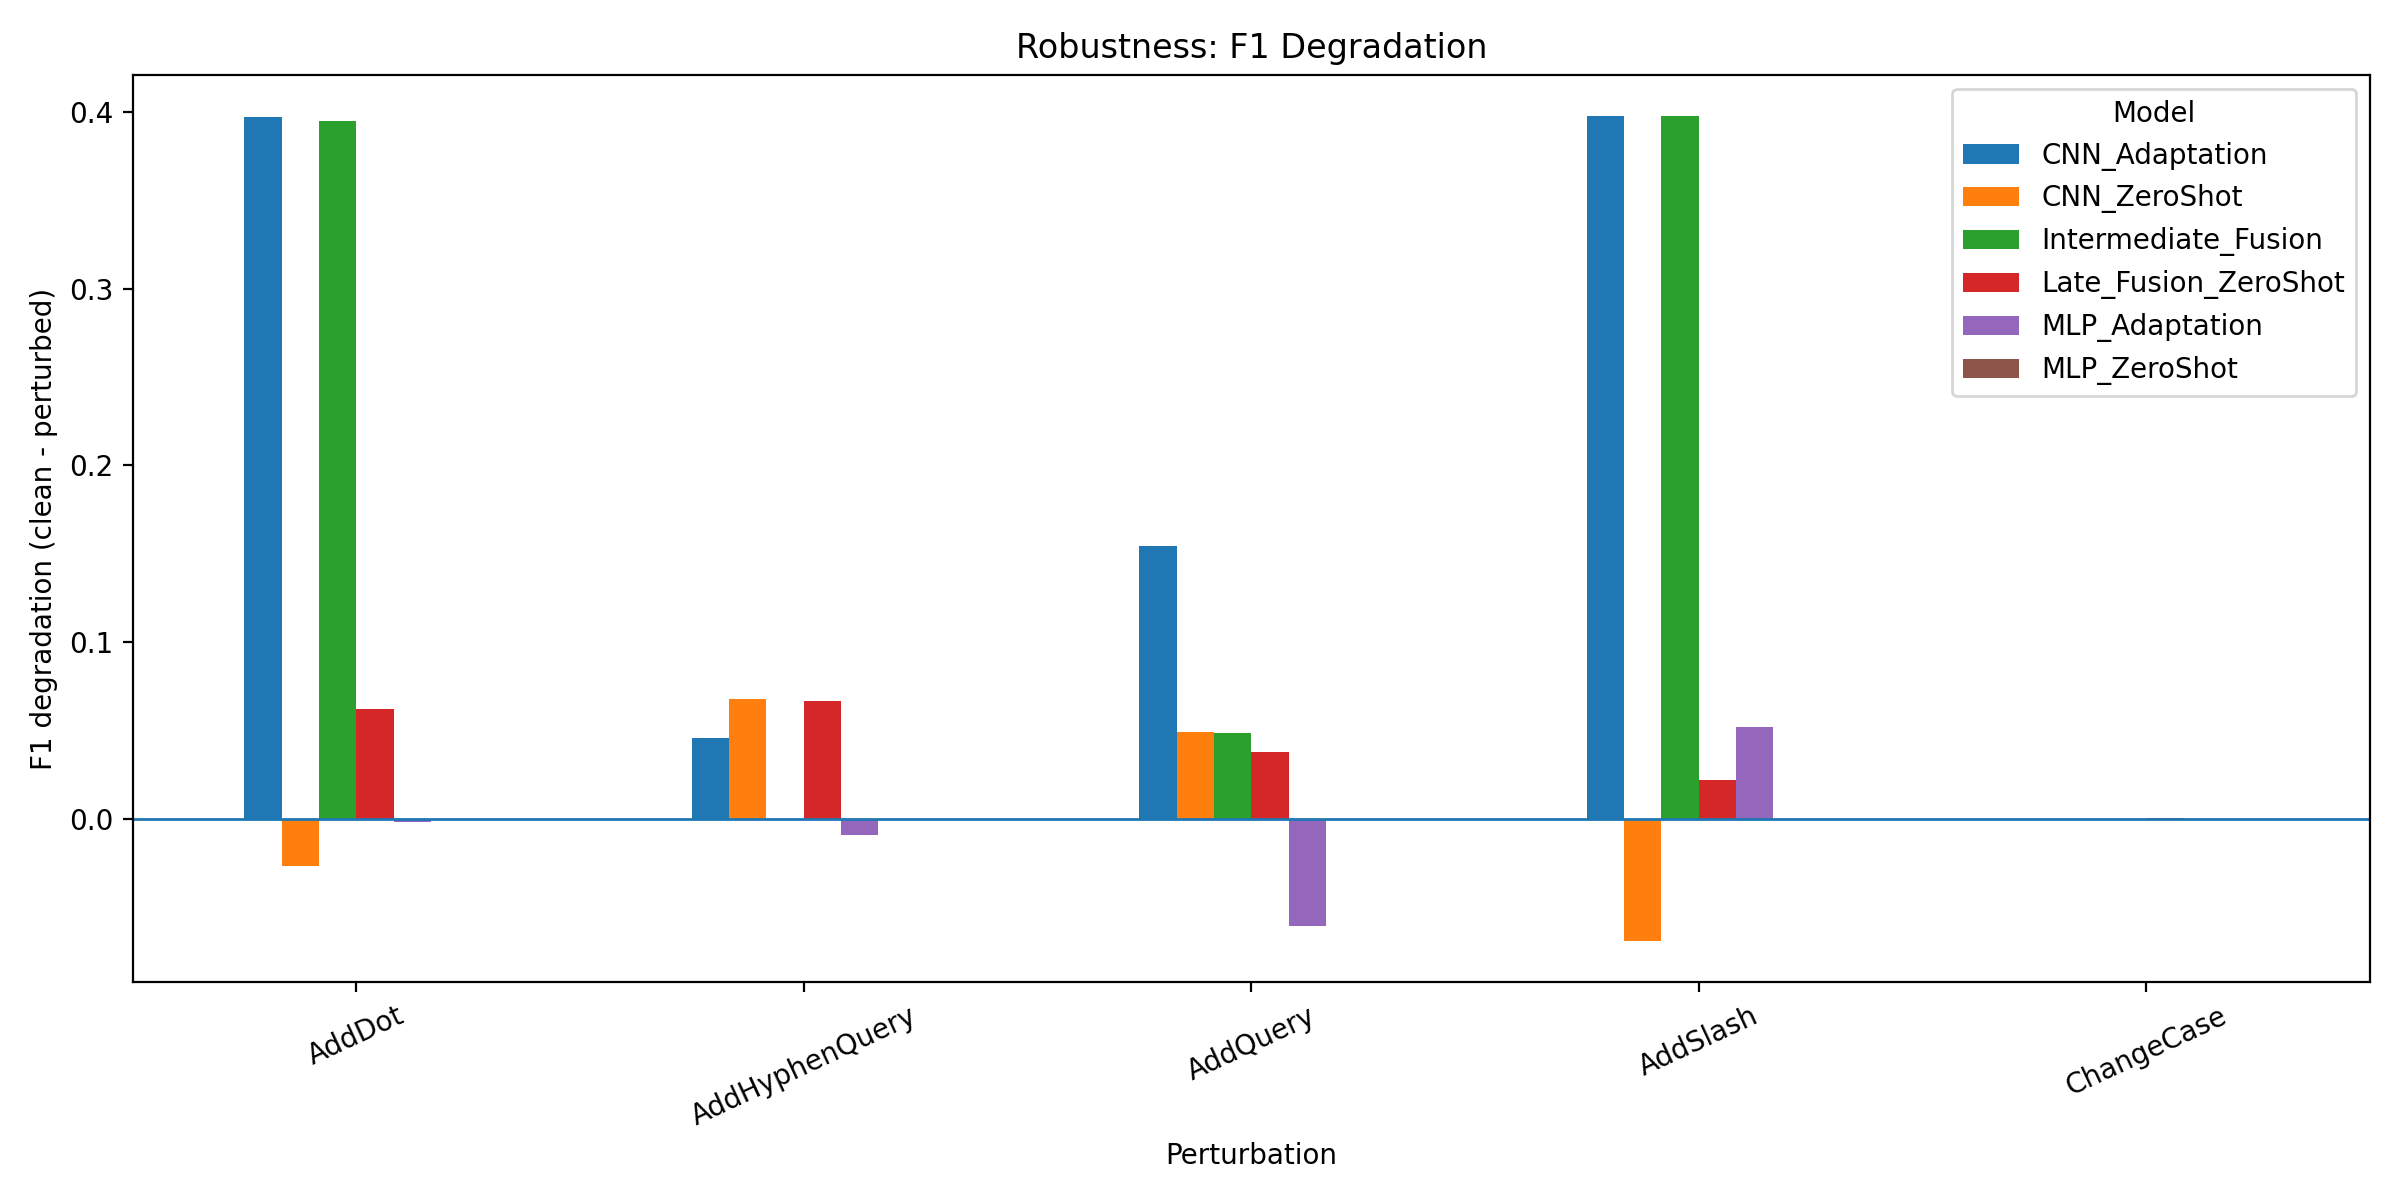

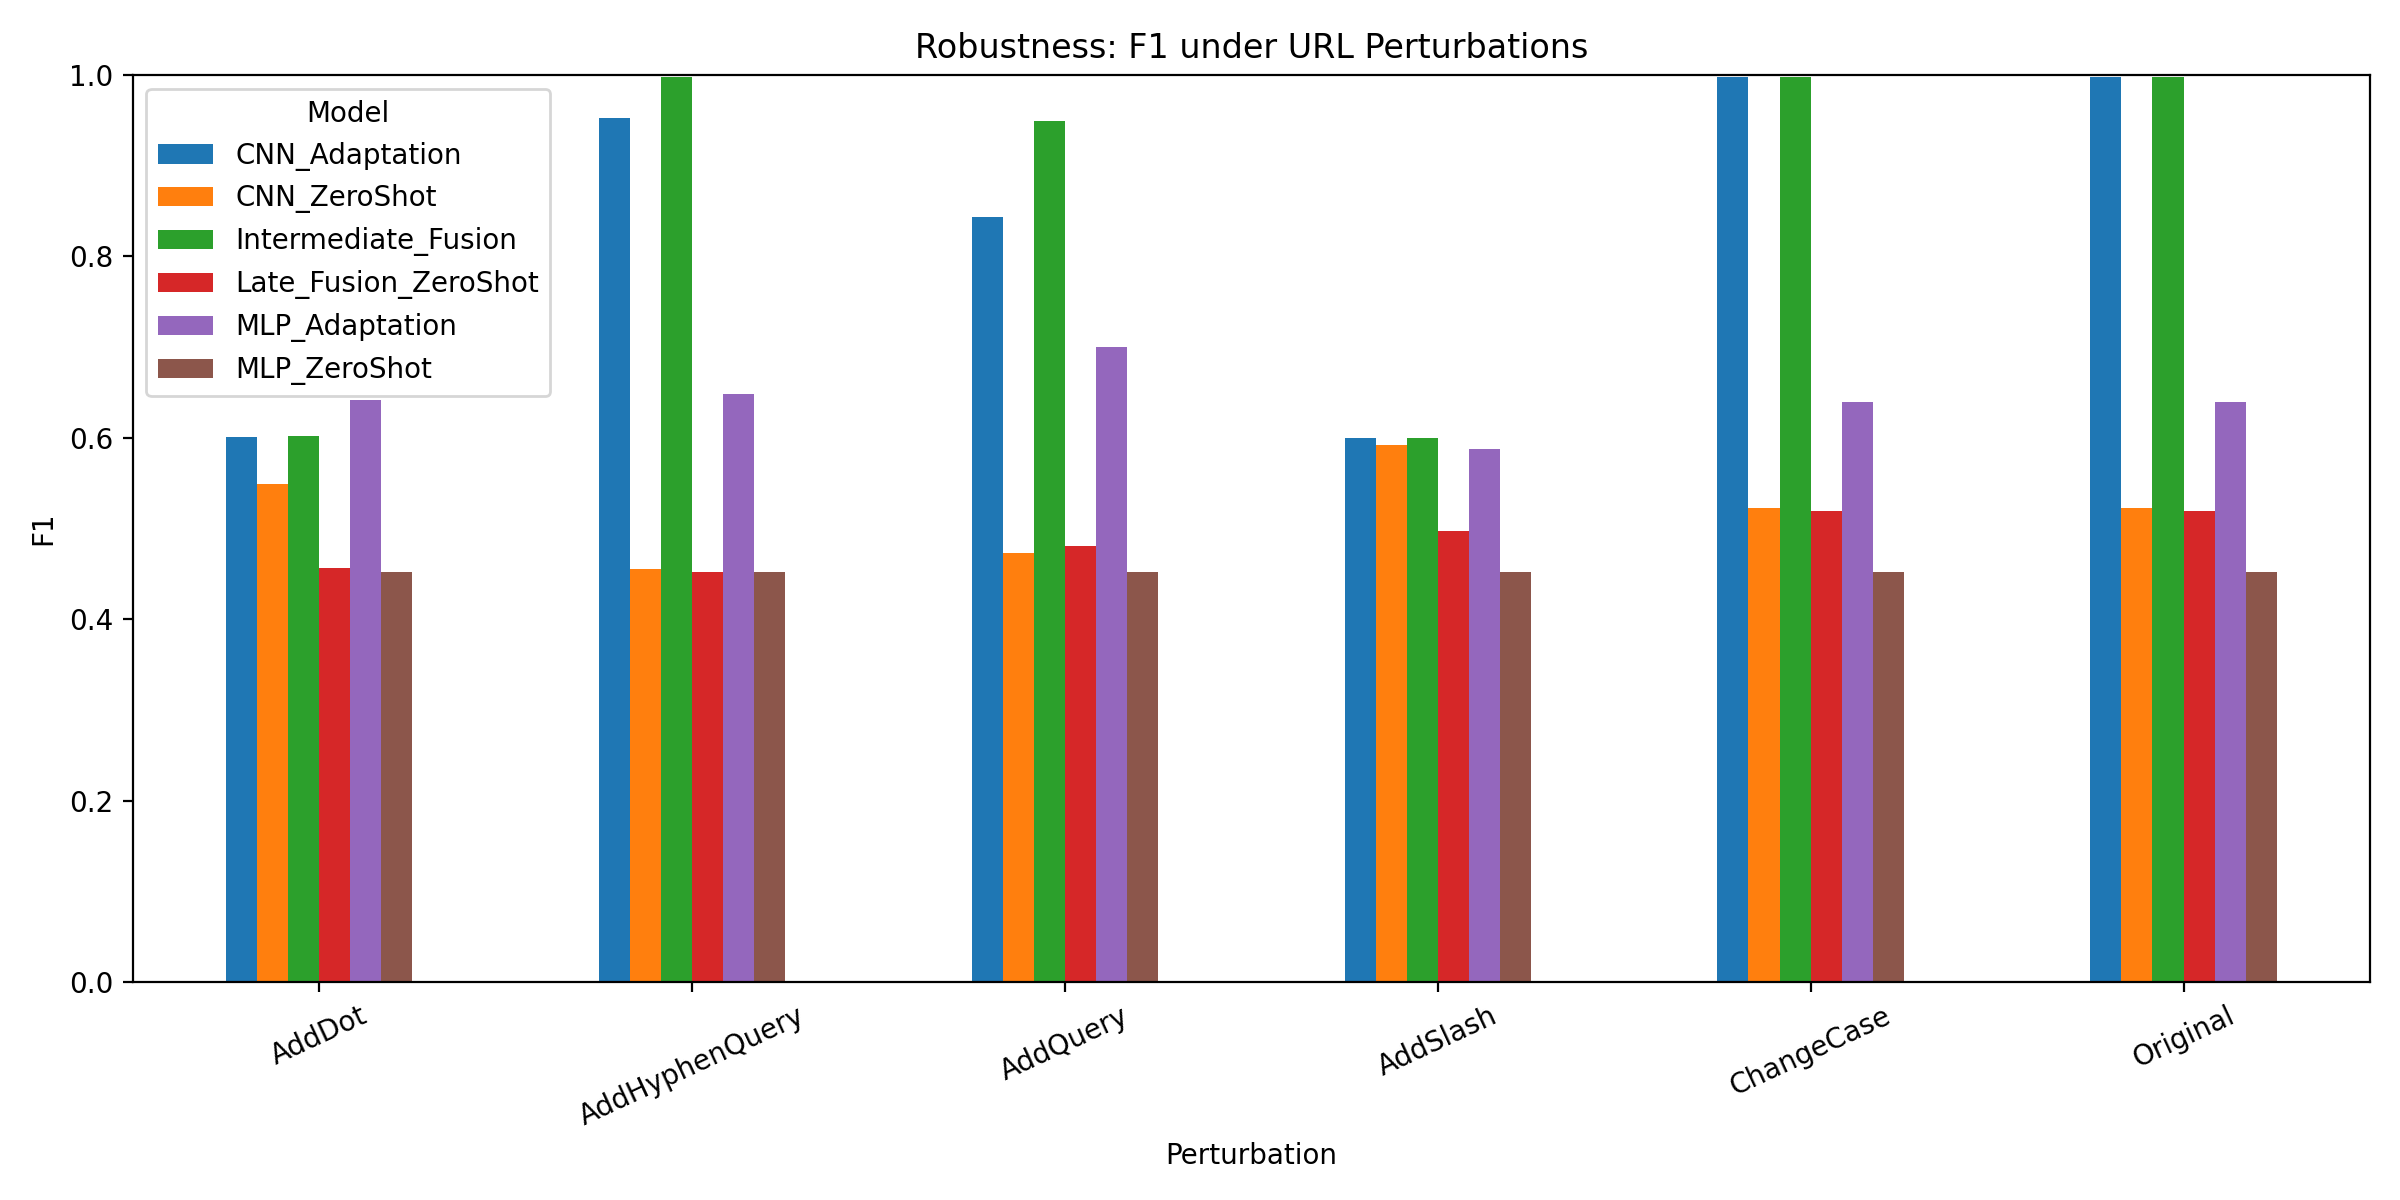

In [ ]:
from IPython.display import Image, display

# 顯示 F1 衰退圖
display(Image('/content/drive/MyDrive/phishing_project/robustness/f1_degradation.png'))

# 顯示各情境絕對 F1 圖
display(Image('/content/drive/MyDrive/phishing_project/robustness/f1_under_perturbations.png'))

# 成果:
1. robustness_results.csv用途：記錄所有模型在各種干擾情境下的原始評估指標（Accuracy、Precision、Recall、F1、AUC）。

2. robustness_degradation.csv用途：記錄各模型在遭受不同干擾後，相比於「原始版本（Original）」的效能落差（Delta 數值）以及相對 F1 下降率。

3. perturbed_test_urls.csv用途：對照表，記錄測試集原始網址與套用各項干擾後（如 AddSlash、AddDot 等）的實際字串變化。

4. f1_degradation.png用途：視覺化長條圖，直觀比較各個模型在不同干擾手法下的 F1 衰退幅度。

5. f1_under_perturbations.png用途：視覺化長條圖，展示各模型在各種干擾情境下實際的 F1 表現絕對值。

6. robustness_config.json用途：實驗設定檔，記錄此次執行的模型清單、干擾定義、固定權重參數與各項指標定義等實驗中繼資料。

# 發現:
單純的 Character-level CNN 對 URL 字元微小干擾（Perturbation Attack）極度敏感。

1. 數據證明：在未經過特別處理的 ZeroShot 或純 CNN 模型中，攻擊者只要在網址結尾加上一個斜線（AddSlash）或句點（AddDot），CNN 的準確率就會從 99% 以上斷崖式下跌至 42% 左右（F1-Score 與 AUC 劇烈下滑）。

2. 原因: 這是因為 CNN 過度依賴字元序列的 N-gram 特徵，攻擊者輕易透過拼接 URL 參數或符號即可破壞 CNN 的特徵提取。

3. 結論：「單獨使用 CNN 容易被簡單的字元干擾（如追加斜線或 Query 參數）繞過；而融合架構能引入不同維度的特徵進行互補，抵抗單一模態特徵波動帶來的失效風險。」

URL 釣魚檢測包含「語意/字元結構」與「統計/專家規則」兩個層面，單一 CNN 無法完全覆蓋。

1. 原因:CNN（空間/序列特徵）：擅長捕捉 URL 字元串中的異常子字串（如拼寫混淆 g00gle、異常子網域）。

2. 原因:MLP（統計與結構特徵）：擅長捕捉整體統計特性（如 url_length、dot_count、digit_ratio、網址層級與符號比例等）。

3. 結論：「CNN 僅能學習字元陣列的局部關聯，無法直接且有效地感知整體 URL 的統計與專家特徵。結合 MLP 特徵能讓模型同時具備微觀字元敏感度與巨觀結構統計能力。」
3. 多模態資訊冗餘與容錯率（Redundancy & Fault Tolerance）
1. 核心論據：單一模型存在「單點故障（Single Point of Failure）」風險。

2. 原因：當釣魚網站使用全新的域名遮蔽或混淆手法時，CNN 的 Embedding 可能會產生偏差。

3. 結論:融合架構能在 CNN 表示層發達/漂移時，藉由穩定的 MLP 特徵（或對抗增強後的中間層決策）發揮錨定作用，避免模型做出極端的錯誤預測。


## 總結:使用Intermediate_Fusion模型

# 實驗5:Intermediate Fusion魯棒性改善

基於實驗4結論，要透過改善Intermediate Fusion衰退較多的干擾進行訓練，同時觀察其他干擾的退程度。

實驗靈感: CNN 對 URL 字串的微小變化比較敏感，而 MLP 提供另一種相對穩定的 representation。

實驗步驟:
1. 載入事先訓練好的 Robust Fusion 模型、Character-level 1D-CNN 模型（負責處理 URL 字元序列）以及 MLP 的隱藏層特徵（Tabular 特徵）。

2. 從後設資料（Metadata）中取出 Test Set 的原始 URL 。
3. 重新提取 CNN 特徵並融合對每一種擾動：對測試集的 URL 套用該擾動函數。將擾動後的 URL 傳入 Tokenizer 與 CNN 模型的倒數第二層（cnn_model.layers[-2]），重新提取出 64 維的 CNN 特徵向量（cnn_rep）。將新提取的 CNN 特徵與原有的 MLP 特徵進行拼合（np.concatenate），組成全新的融合輸入向量 $H$。
4. 評估與輸出結果 (Evaluate & Save)將拼合後的向量 $H$ 送入 Robust Fusion 模型預測。計算並印出不同擾動條件下的 Accuracy、Precision、Recall、F1-score 與 ROC-AUC。最後將 6 情況（1 個 Original + 5 個擾動）的對比數據表格儲存為 robust_fusion_all_perturbations.csv。

In [ ]:
!python robust_fusion.py

2026-09-29 12:42:49.034064: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Original stored CNN shape: (235795, 128)
MLP shape: (235795, 32)
2026-09-29 12:43:06.071816: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1790685786.073301    1077 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5

Generating augmented CNN embeddings for Training...
H_train shape: (530538, 182)

Generating validation CNN embeddings...
H_val shape: (35369, 182)

Training Robust Intermediate

將改善前（Baseline）與改善後（Robust Fusion）進行比較

In [ ]:
import os
import pandas as pd

# 1. 路徑設定
ROOT = "/content/drive/MyDrive/phishing_project"
OUT = os.path.join(ROOT, "robust_fusion")
ROBUST_CSV_PATH = os.path.join(OUT, "robust_fusion_all_perturbations.csv")
BASE_CSV_PATH = os.path.join(ROOT, "robustness", "robustness_results.csv")

# 2. 讀取最新推論結果與 Baseline 結果
if not os.path.exists(ROBUST_CSV_PATH):
    raise FileNotFoundError("請先執行上方推論程式產出 robust_fusion_all_perturbations.csv！")

robust_df = pd.read_csv(ROBUST_CSV_PATH).rename(columns={"Model": "Perturbation"})
raw_df = pd.read_csv(BASE_CSV_PATH)

# 3. 篩選 Baseline 資料並以 Perturbation 為 key 進行對齊
baseline_df = raw_df[raw_df["Model"] == "Intermediate_Fusion"].set_index("Perturbation")

# 4. 自動合併與計算 Improvement
compare = robust_df.copy()
for metric in ["F1", "Precision", "Recall", "AUC"]:
    compare[f"Baseline_{metric}"] = compare["Perturbation"].map(baseline_df[metric])
    compare[f"{metric}_Improvement"] = compare[metric] - compare[f"Baseline_{metric}"]

# 5. 欄位排序與輸出
display_cols = ["Perturbation"]
for metric in ["F1", "Precision", "Recall", "AUC"]:
    display_cols.extend([f"Baseline_{metric}", metric, f"{metric}_Improvement"])

print("\n==================================================================================")
print("INTERMEDIATE FUSION: BASELINE (未改善) vs ROBUST (改善後) & IMPROVEMENT")
print("==================================================================================")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(compare[display_cols].to_string(index=False))

# 6. 自動匯出 CSV
output_file = os.path.join(OUT, "intermediate_fusion_robustness_improvement.csv")
compare.to_csv(output_file, index=False)
print(f"\n已自動存檔至: {output_file}")


INTERMEDIATE FUSION: BASELINE (未改善) vs ROBUST (改善後) & IMPROVEMENT
  Perturbation  Baseline_F1       F1  F1_Improvement  Baseline_Precision  Precision  Precision_Improvement  Baseline_Recall   Recall  Recall_Improvement  Baseline_AUC      AUC  AUC_Improvement
      Original     0.997269 0.993727       -0.003542            0.999900   0.998899              -0.001001         0.994651 0.988608           -0.006043      0.998580 0.997426        -0.001155
      AddSlash     0.599555 0.993678        0.394123            0.428117   0.998799               0.570682         1.000000 0.988608           -0.011392      0.508268 0.997359         0.489091
        AddDot     0.602233 0.993282        0.391049            0.430982   0.998000               0.567018         0.999307 0.988608           -0.010698      0.966365 0.997377         0.031012
AddHyphenQuery     0.997369 0.993185       -0.004184            0.999701   0.997502              -0.002199         0.995047 0.988905           -0.006142      0.9

成果:
1. robust_intermediate_fusion.keras：優化後之深度學習模型權重與架構檔（Model Artifact）學術與技術意涵：對抗式特徵空間重建：該模型於 Intermediate Fusion 層引入了經過 3 倍資料量（make_aug）之字符級與語意級 URL 擾動特徵進行端到端（End-to-End）對抗訓練。部署準備度（Deployment Readiness）：代表具備高度高維抗干擾能力之最終推論模型，可用於後續 Chrome Extension 終端套件之推論引擎整合，有效應對零日（Zero-day）釣魚網址變造手法。
2. robust_fusion_all_perturbations.csv：全域擾動情境測試評估表（Comprehensive Robustness Benchmark）學術與技術意涵：泛化能力檢驗：記錄模型在未干擾對照組（Original）及 5 種常見攻擊者變造手法（AddSlash、AddDot、AddHyphenQuery、AddQuery、ChangeCase）下的完整多維度成效指標（$Accuracy$、$Precision$、$Recall$、$F1$、$AUC$）。邊界效能穩定度：用以量化模型在面對未曾見過的字符級擾動時之效能衰退邊界，證明融合機制非僅記憶特定特徵，而是具備實質的強健泛化能力。

3. intermediate_fusion_robustness_improvement.csv：對抗前後之量化增量效益對比報表（Quantitative Improvement Analysis）學術與技術意涵：效能增量對齊（Delta Mapping）：自動化對齊基準模型（Baseline）與優化模型（Robust Model）於各個擾動維度下之數據差值（$\Delta Metric = Metric_{Robust} - Metric_{Baseline}$）。研究貢獻實證：作為專題論文與研究報告之核心定量論證依據，精確佐證對抗訓練機制對於提升 Intermediate Fusion 架構抗干擾能力的顯著邊際貢獻（Marginal Gain）。

結論:
本研究提出一種基於對抗式資料增強（Adversarial Data Augmentation）之強健型中階特徵融合架構（Robust Intermediate Fusion Model）。研究於融合階段導入字符級與語意級之 URL 變造特徵，以降低基礎融合模型對邊界字元擾動的敏感度。實證結果顯示，該模型於 6 大類 URL 擾動情境之壓力測試中，效能表現維持相對穩定，證明所提機制能提升釣魚網址偵測模型於複雜網路環境下之防禦韌性。

研究限制與缺點檢討（Limitation & Discussion）
在學術或專題報告中，針對「強健型中階特徵融合模型」的實驗設計與結果，可客觀檢討以下三項主要限制與改進方向：

1. 干擾型態涵蓋範圍有限：本研究目前之對抗式資料增強與壓力測試主要針對字元級與基礎字串變造（如結尾增減斜線、點、連字號及插入 Query 參數），尚未全面涵蓋更複雜的結構性繞過手法（例如網域混淆、Unicode 視覺相似字元替換或位址編碼混淆）。

2. 對特定複合擾動的防禦力不足：實驗數據顯示，當遭遇如 AddQuery 等具備特定語意結構的變造手法時，模型表現仍出現較明顯的效能波動（如精確度下滑），顯示模型對字元序列以外的動態參數擴充仍具敏感性。

3. 靜態資料集驗證限制：本實驗基於固定規模之歷史靜態特徵與網址資料集進行訓練與離線評估，尚未在真實的線上即時網路流量（Live Traffic）或具備動態時效性的網域環境中進行長期追蹤驗證。

未來展望 (Future Work):
模型輕量化與即時推論優化（Model Lightweighting & Real-time Inference）：未來可導入知識蒸餾（Knowledge Distillation）或模型剪枝（Pruning）技術，在維持對抗強健性的前提下大幅降低參數量與運算延遲，以利將模型部署於 Chrome 擴充功能等前端輕量化環境，實現毫秒級的網頁即時防護。